In [1]:
from helpers import main
from matplotlib import pyplot as plt

In [2]:
instrument_name = "SOFI"
# instrument_name = "ESPRESSO"
# instrument_name = "NIRPS"
final_table, N = main(instrument_name, maxrec=100, max_workers=20)
# final_table = main(instrument_name, maxrec=100, max_workers=8)

final_table_SOFI.fits does not exist, performing query.


Querying SIMBAD: 100%|██████████| 100/100 [00:03<00:00, 26.81it/s]


In [3]:
final_table

dp_id,target_name,collection,prov1,ra,dec,ra_prov,dec_prov,ra_tel,dec_tel,ra_prov_tel,dec_prov_tel,ra_simbad,dec_simbad
,,,,deg,deg,,,deg,deg,deg,deg,,
str27,str20,str6,str33,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
ADP.2014-01-20T10:01:42.477,SN2012ec,PESSTO,SOFI.2013-02-08T00:51:07.635.fits,41.4995,-7.57417,41.49941,-7.57768,41.49945833333333,-7.574166666666667,41.49945833333333,-7.574166666666667,41.499542,-7.573611
ADP.2014-01-20T10:01:42.557,SN2012ca,PESSTO,SOFI.2012-09-25T00:17:33.906.fits,280.28021,-41.794,280.2833,-41.78734,280.28020833333335,-41.793972222222216,280.28020833333335,-41.793972222222216,280.280208,-41.794
ADP.2014-01-20T10:01:42.670,SN2009ip,PESSTO,SOFI.2012-10-17T05:27:08.637.fits,335.78467,-28.947779,335.78433,-28.9521,335.7846666666667,-28.947777777777777,335.7846666666667,-28.947777777777777,335.784417,-28.947889
ADP.2014-01-20T10:01:42.677,SN2012fr,PESSTO,SOFI.2012-11-14T08:22:50.126.fits,53.400416,-36.126111,53.40109,-36.13112,53.40041666666666,-36.12608333333334,53.40041666666666,-36.12608333333334,53.399958,-36.127139
ADP.2014-01-20T10:01:42.703,SN2012fr,PESSTO,SOFI.2013-01-04T03:46:15.180.fits,53.400416,-36.126111,53.40077,-36.13354,53.40041666666666,-36.12608333333334,53.40041666666666,-36.12608333333334,53.399958,-36.127139
ADP.2014-01-20T10:01:42.743,SN2012hs,PESSTO,SOFI.2013-01-29T07:25:51.544.fits,147.311291,-47.912666,147.31213,-47.91728,147.31124999999997,-47.91266666666666,147.31124999999997,-47.91266666666666,147.311292,-47.912667
ADP.2014-01-20T10:01:42.897,SN2012hs,PESSTO,SOFI.2013-01-29T06:27:35.725.fits,147.311291,-47.912666,147.31213,-47.91728,147.31124999999997,-47.91266666666666,147.31124999999997,-47.91266666666666,147.311292,-47.912667
ADP.2014-01-20T10:01:42.923,SN2012fr,PESSTO,SOFI.2012-12-05T05:59:29.700.fits,53.400416,-36.126111,53.39644,-36.12805,53.40041666666666,-36.12608333333334,53.40041666666666,-36.12608333333334,53.399958,-36.127139


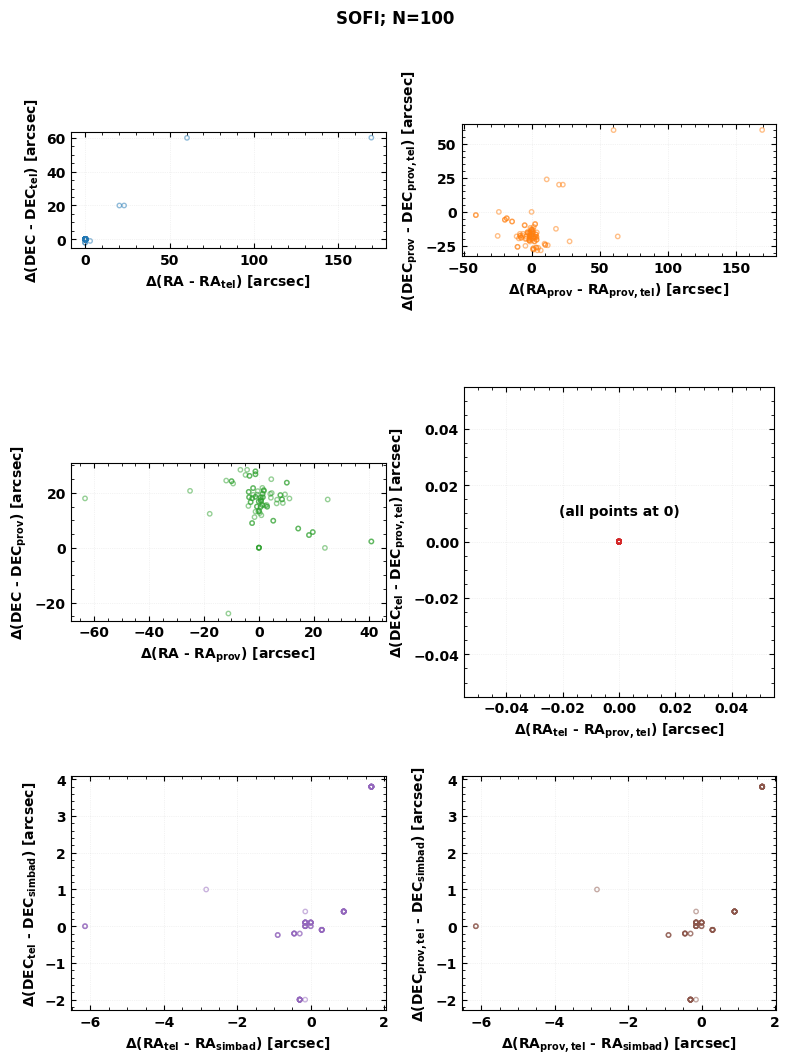

In [4]:
fig = plt.figure(figsize=(8,11))

ax1 = fig.add_subplot(321, aspect='equal')
ax2 = fig.add_subplot(322, aspect='equal')
ax3 = fig.add_subplot(323, aspect='equal')
ax4 = fig.add_subplot(324, aspect='equal')
ax5 = fig.add_subplot(325, aspect='equal')
ax6 = fig.add_subplot(326, aspect='equal')

ax1.scatter((final_table['ra'] - final_table['ra_tel'])*3600,
              (final_table['dec'] - final_table['dec_tel'])*3600, 
              alpha=0.5, s=10, facecolors='none', edgecolors='C0') 

ax2.scatter((final_table['ra_prov'] - final_table['ra_prov_tel'])*3600,
              (final_table['dec_prov'] - final_table['dec_prov_tel'])*3600,
              alpha=0.5, s=10, facecolors='none', edgecolors='C1') 

ax3.scatter((final_table['ra'] - final_table['ra_prov'])*3600,
              (final_table['dec'] - final_table['dec_prov'])*3600,
              alpha=0.5, s=10, facecolors='none', edgecolors='C2') 

ax4.scatter((final_table['ra_tel'] - final_table['ra_prov_tel'])*3600,
              (final_table['dec_tel'] - final_table['dec_prov_tel'])*3600,
              alpha=0.5, s=10, facecolors='none', edgecolors='C3') 

ax5.scatter((final_table['ra_tel'] - final_table['ra_simbad'])*3600,
              (final_table['dec_tel'] - final_table['dec_simbad'])*3600,
              alpha=0.5, s=10, facecolors='none', edgecolors='C4') 

ax6.scatter((final_table['ra_prov_tel'] - final_table['ra_simbad'])*3600,
              (final_table['dec_prov_tel'] - final_table['dec_simbad'])*3600,
              alpha=0.5, s=10, facecolors='none', edgecolors='C5')

if (sum(final_table['ra'] - final_table['ra_prov']) == 0) and (sum(final_table['dec'] - final_table['dec_prov']) == 0):
    ax3.text(0.5, 0.6, '(all points at 0)', weight='bold', ha='center', va='center', transform=ax3.transAxes) 

if (sum(final_table['ra_tel'] - final_table['ra_prov_tel']) == 0) and (sum(final_table['dec_tel'] - final_table['dec_prov_tel']) == 0):
    ax4.text(0.5, 0.6, '(all points at 0)', weight='bold', ha='center', va='center', transform=ax4.transAxes)

ax1.set_xlabel(r'$\Delta$(RA - RA$_\mathrm{tel}$) [arcsec]')
ax1.set_ylabel(r'$\Delta$(DEC - DEC$_\mathrm{tel}$) [arcsec]')
ax2.set_xlabel(r'$\Delta$(RA$_\mathrm{prov}$ - RA$_\mathrm{prov, tel}$) [arcsec]')
ax2.set_ylabel(r'$\Delta$(DEC$_\mathrm{prov}$ - DEC$_\mathrm{prov, tel}$) [arcsec]')
ax3.set_xlabel(r'$\Delta$(RA - RA$_\mathrm{prov}$) [arcsec]')
ax3.set_ylabel(r'$\Delta$(DEC - DEC$_\mathrm{prov}$) [arcsec]')
ax4.set_xlabel(r'$\Delta$(RA$_\mathrm{tel}$ - RA$_\mathrm{prov, tel}$) [arcsec]')
ax4.set_ylabel(r'$\Delta$(DEC$_\mathrm{tel}$ - DEC$_\mathrm{prov, tel}$) [arcsec]')
ax5.set_xlabel(r'$\Delta$(RA$_\mathrm{tel}$ - RA$_\mathrm{simbad}$) [arcsec]')
ax5.set_ylabel(r'$\Delta$(DEC$_\mathrm{tel}$ - DEC$_\mathrm{simbad}$) [arcsec]')
ax6.set_xlabel(r'$\Delta$(RA$_\mathrm{prov, tel}$ - RA$_\mathrm{simbad}$) [arcsec]')
ax6.set_ylabel(r'$\Delta$(DEC$_\mathrm{prov, tel}$ - DEC$_\mathrm{simbad}$) [arcsec]')

fig.suptitle(f'{instrument_name}; N={N}', weight='bold')
fig.tight_layout()
fig.savefig(f'coord_differences_{instrument_name}.png')

In [5]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=3, cols=2)

def add_scatter(row, col, x, y, color):
    fig.add_trace(
        go.Scattergl(
            x=x, y=y, mode="markers",
            marker=dict(size=6, color=color, line=dict(width=1, color=color)),
            opacity=0.5,
            customdata=hover_data,
            hovertemplate="dp_id=%{customdata[0]}<br>target=%{customdata[1]}<br>x=%{x:.3f}<br>y=%{y:.3f}<extra></extra>",
        ),
        row=row, col=col,
    )

# Precompute diffs (arcsec)
x1 = (final_table['ra'] - final_table['ra_tel']) * 3600
y1 = (final_table['dec'] - final_table['dec_tel']) * 3600

x2 = (final_table['ra_prov'] - final_table['ra_prov_tel']) * 3600
y2 = (final_table['dec_prov'] - final_table['dec_prov_tel']) * 3600

x3 = (final_table['ra'] - final_table['ra_prov']) * 3600
y3 = (final_table['dec'] - final_table['dec_prov']) * 3600

x4 = (final_table['ra_tel'] - final_table['ra_prov_tel']) * 3600
y4 = (final_table['dec_tel'] - final_table['dec_prov_tel']) * 3600

x5 = (final_table['ra_tel'] - final_table['ra_simbad']) * 3600
y5 = (final_table['dec_tel'] - final_table['dec_simbad']) * 3600

x6 = (final_table['ra_prov_tel'] - final_table['ra_simbad']) * 3600
y6 = (final_table['dec_prov_tel'] - final_table['dec_simbad']) * 3600

hover_data = np.column_stack([
    np.array(final_table["dp_id"], dtype=str),
    np.array(final_table["target_name"], dtype=str),
])

def add_scatter(row, col, x, y, color):
    fig.add_trace(
        go.Scattergl(
            x=x, y=y,
            mode="markers",
            marker=dict(size=6, color=color, line=dict(width=1, color=color)),
            opacity=0.5,
            customdata=hover_data,
            hovertemplate="dp_id=%{customdata[0]}<br>target=%{customdata[1]}<br>x=%{x:.3f}<br>y=%{y:.3f}<extra></extra>",
        ),
        row=row, col=col,
    )

add_scatter(1, 1, x1, y1, "red")
add_scatter(1, 2, x2, y2, "orange")
add_scatter(2, 1, x3, y3, "yellow")
add_scatter(2, 2, x4, y4, "green")
add_scatter(3, 1, x5, y5, "blue")
add_scatter(3, 2, x6, y6, "purple")

# axis labels
fig.update_xaxes(title_text=r'Δ(RA - RA_tel) [arcsec]', row=1, col=1)
fig.update_yaxes(title_text=r'Δ(DEC - DEC_tel) [arcsec]', row=1, col=1)

fig.update_xaxes(title_text=r'Δ(RA_prov - RA_prov,tel) [arcsec]', row=1, col=2)
fig.update_yaxes(title_text=r'Δ(DEC_prov - DEC_prov,tel) [arcsec]', row=1, col=2)

fig.update_xaxes(title_text=r'Δ(RA - RA_prov) [arcsec]', row=2, col=1)
fig.update_yaxes(title_text=r'Δ(DEC - DEC_prov) [arcsec]', row=2, col=1)

fig.update_xaxes(title_text=r'Δ(RA_tel - RA_prov,tel) [arcsec]', row=2, col=2)
fig.update_yaxes(title_text=r'Δ(DEC_tel - DEC_prov,tel) [arcsec]', row=2, col=2)

fig.update_xaxes(title_text=r'Δ(RA_tel - RA_simbad) [arcsec]', row=3, col=1)
fig.update_yaxes(title_text=r'Δ(DEC_tel - DEC_simbad) [arcsec]', row=3, col=1)

fig.update_xaxes(title_text=r'Δ(RA_prov,tel - RA_simbad) [arcsec]', row=3, col=2)
fig.update_yaxes(title_text=r'Δ(DEC_prov,tel - DEC_simbad) [arcsec]', row=3, col=2)

# annotate if all zeros
if np.nansum(final_table['ra'] - final_table['ra_prov']) == 0 and np.nansum(final_table['dec'] - final_table['dec_prov']) == 0:
    fig.add_annotation(text="(all points at 0)", x=0.5, y=0.6, xref="x3 domain", yref="y3 domain", showarrow=False)
if np.nansum(final_table['ra_tel'] - final_table['ra_prov_tel']) == 0 and np.nansum(final_table['dec_tel'] - final_table['dec_prov_tel']) == 0:
    fig.add_annotation(text="(all points at 0)", x=0.5, y=0.6, xref="x4 domain", yref="y4 domain", showarrow=False)

fig.update_layout(
    title=dict(text=f"{instrument_name}; N={N}", x=0.5, xanchor="center"),
    height=900,
    width=800,
    showlegend=False,
)

fig.write_html(f"coord_differences_{instrument_name}.html", include_plotlyjs="cdn")